In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.models import Model

In [ ]:
base_path = "/content/drive/MyDrive/DS1/Mendaly"

classes = {
    "COVID2_CT": 0,
    "pneumonia_CT": 1,
    "Normal_CT": 2
}

In [ ]:
IMG_SIZE = 224
X = []
y = []

for class_name, label in classes.items():
    folder = os.path.join(base_path, class_name)

    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)

        try:
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            X.append(img)
            y.append(label)
        except:
            pass

X = np.array(X)
y = np.array(y)

X = preprocess_input(X)

print("Total Images:", len(X))

Total Images: 4513


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [ ]:
base_model = DenseNet121(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

model = Model(inputs=base_model.input, outputs=base_model.output)

X_train_feat = model.predict(X_train)
X_test_feat = model.predict(X_test)

X_train_feat = X_train_feat.reshape(X_train_feat.shape[0], -1)
X_test_feat = X_test_feat.reshape(X_test_feat.shape[0], -1)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
99/99 ━━━━━━━━━━━━━━━━━━━━ 519s 5s/step
43/43 ━━━━━━━━━━━━━━━━━━━━ 217s 5s/step


In [ ]:
svm = SVC(kernel='linear')
svm.fit(X_train_feat, y_train)

y_pred_svm = svm.predict(X_test_feat)

In [ ]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train_feat, y_train)

y_pred_rf = rf.predict(X_test_feat)

In [ ]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_feat, y_train)

y_pred_lr = lr.predict(X_test_feat)

In [ ]:
print("\nSVM")
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_svm, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_svm, average='weighted'))

print("\nRandom Forest")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_rf, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_rf, average='weighted'))

print("\nLogistic Regression")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred_lr, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred_lr, average='weighted'))


SVM
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0

Random Forest
Accuracy : 0.9970457902511078
Precision: 0.9970643994463763
Recall   : 0.9970457902511078
F1 Score : 0.9970455883998588

Logistic Regression
Accuracy : 0.9992614475627769
Precision: 0.9992626161584055
Recall   : 0.9992614475627769
F1 Score : 0.9992608910321501


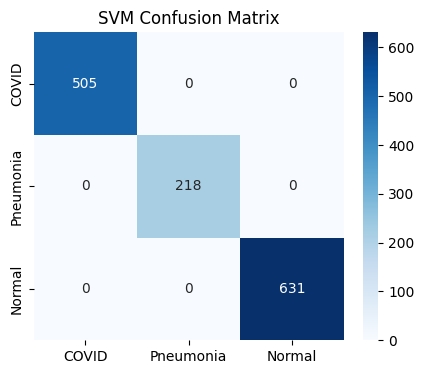

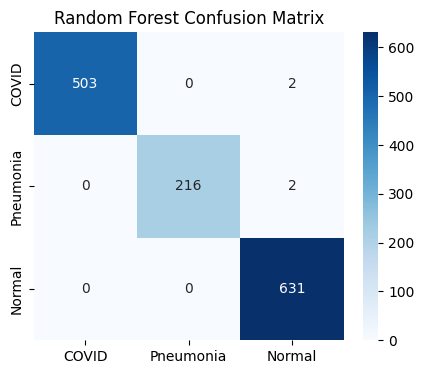

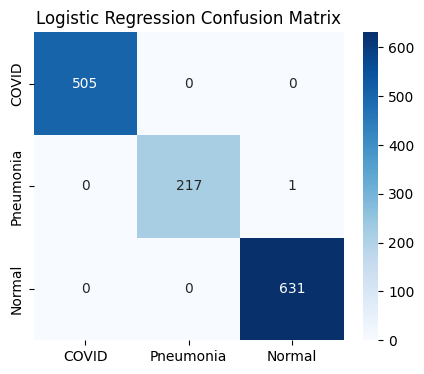

In [ ]:
models = {
    "SVM": y_pred_svm,
    "Random Forest": y_pred_rf,
    "Logistic Regression": y_pred_lr
}

for name, pred in models.items():
    cm = confusion_matrix(y_test, pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['COVID','Pneumonia','Normal'],
                yticklabels=['COVID','Pneumonia','Normal'])
    plt.title(name + " Confusion Matrix")
    plt.show()

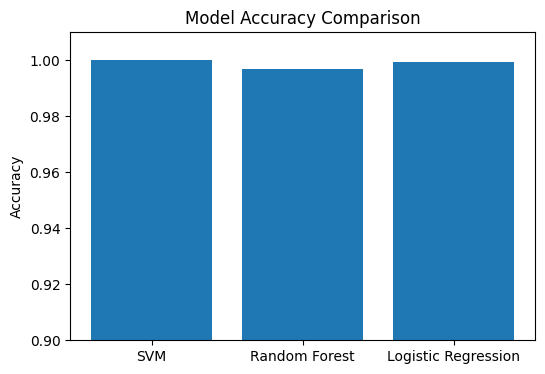

In [ ]:
model_names = ['SVM', 'Random Forest', 'Logistic Regression']
accuracies = [
    accuracy_score(y_test, y_pred_svm),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_lr)
]

plt.figure(figsize=(6,4))
plt.bar(model_names, accuracies)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0.9,1.01)
plt.show()